# Assignment 3

### Loading the dataset or transcripts

In [ ]:
import pandas as pd
import requests, pickle

comedians = ['ali', 'anthony', 'bill', 'bo', 'dave', 'hasan', 'jim', 'joe', 'john', 'louis', 'mike', 'ricky']
data = {}
for c in comedians:
    url = f'https://raw.githubusercontent.com/nwams/nlp-stand-up-comedy/master/transcripts/{c}.txt'
    data[c] = requests.get(url).text

### Top 30 words + word cloud

[('like', np.int64(1552)), ('iâ', np.int64(1245)), ('know', np.int64(797)), ('just', np.int64(777)), ('donâ', np.int64(710)), ('itâ', np.int64(694)), ('right', np.int64(547)), ('youâ', np.int64(521)), ('thatâ', np.int64(480)), ('people', np.int64(416)), ('said', np.int64(366)), ('got', np.int64(350)), ('fucking', np.int64(326)), ('think', np.int64(315)), ('gonna', np.int64(307)), ('theyâ', np.int64(283)), ('ve', np.int64(279)), ('shit', np.int64(265)), ('heâ', np.int64(255)), ('time', np.int64(250)), ('say', np.int64(245)), ('weâ', np.int64(238)), ('ll', np.int64(233)), ('œi', np.int64(230)), ('fuck', np.int64(224)), ('going', np.int64(216)), ('didnâ', np.int64(208)), ('want', np.int64(205)), ('day', np.int64(198)), ('thing', np.int64(198))]


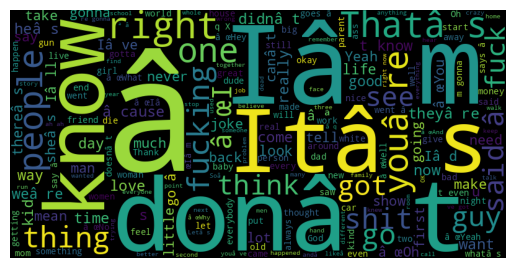

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

cv = CountVectorizer(stop_words='english')
dtm = cv.fit_transform(data.values())
word_counts = dtm.sum(axis=0).A1
words = cv.get_feature_names_out()
top30 = sorted(zip(words, word_counts), key=lambda x: -x[1])[:30]
print(top30)

wc = WordCloud(width=800, height=400).generate(' '.join(data.values()))
plt.imshow(wc)
plt.axis('off')
plt.show()

### Update stop words and redo word cloud

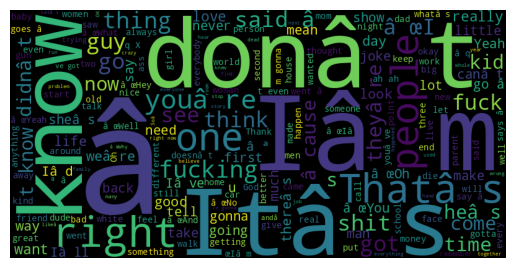

In [ ]:
extra_stop = ['like', 'just', 'know', 'gonna', 'im', 'thats', 'yeah']
cv2 = CountVectorizer(stop_words=list(cv.get_stop_words()) + extra_stop)
dtm2 = cv2.fit_transform(data.values())
wc2 = WordCloud(width=800, height=400).generate(' '.join(data.values()))
plt.imshow(wc2)
plt.axis('off')
plt.show()

### Unique words per comedian

In [ ]:
unique_counts = {}
for c, text in data.items():
    words_used = set(text.lower().split())
    unique_counts[c] = len(words_used)
print(unique_counts)

{'ali': 2111, 'anthony': 1775, 'bill': 2876, 'bo': 2184, 'dave': 2412, 'hasan': 2808, 'jim': 2534, 'joe': 2527, 'john': 2409, 'louis': 1992, 'mike': 2597, 'ricky': 2971}


### Words per minute

{'ali': 122.56666666666666, 'anthony': 113.55932203389831, 'bill': 152.725, 'bo': 119.1, 'dave': 136.56716417910448, 'hasan': 143.82191780821918, 'jim': 144.0909090909091, 'joe': 157.85714285714286, 'john': 149.91935483870967, 'louis': 128.9655172413793, 'mike': 150.55263157894737, 'ricky': 133.7594936708861}


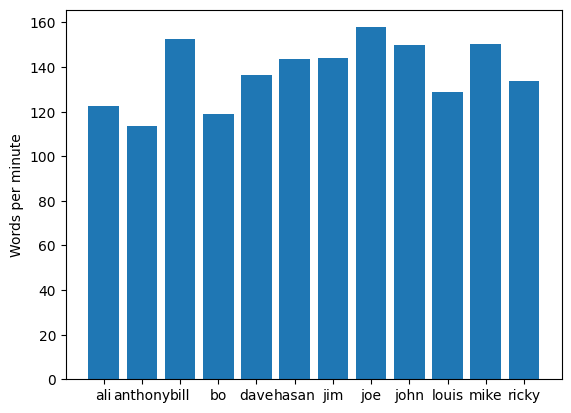

In [ ]:
run_times = [60, 59, 80, 60, 67, 73, 77, 63, 62, 58, 76, 79]
wpm = {}
for c, rt in zip(comedians, run_times):
    total_words = len(data[c].split())
    wpm[c] = total_words / rt
print(wpm)

plt.bar(wpm.keys(), wpm.values())
plt.ylabel('Words per minute')
plt.show()

### Scatter plot of word categories (e.g. bad words vs total words)

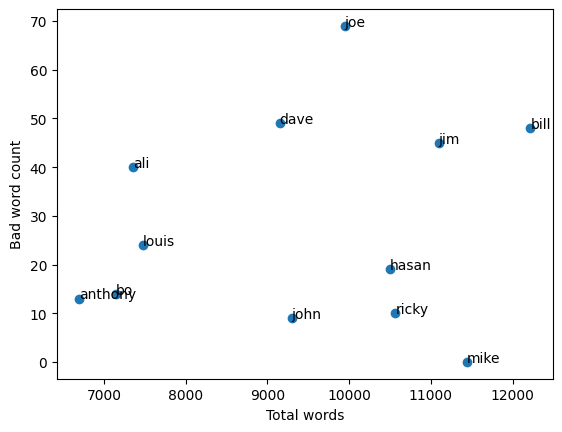

In [ ]:
bad_words = ['fuck', 'shit', 'damn', 'ass', 'bitch']

x = []
y = []
for c, text in data.items():
    lower = text.lower().split()
    bad_count = sum(lower.count(w) for w in bad_words)
    x.append(len(lower))
    y.append(bad_count)

plt.scatter(x, y)
for i, c in enumerate(comedians):
    plt.annotate(c, (x[i], y[i]))
plt.xlabel('Total words')
plt.ylabel('Bad word count')
plt.show()

### Alternative scatter plot (comparing pronoun usage vs unique words instead of bad words)

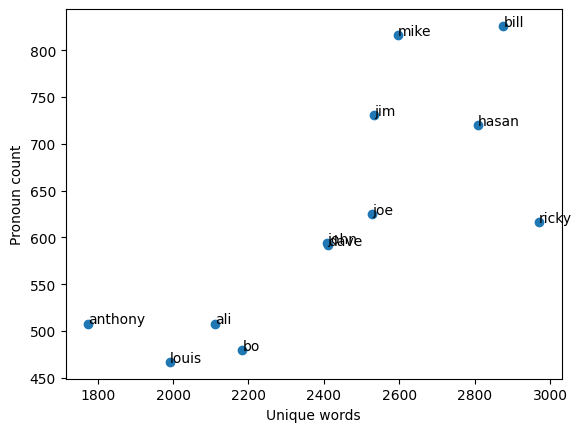

In [7]:
pronouns = ['i', 'you', 'we', 'they']

x2 = []
y2 = []
for c, text in data.items():
    lower = text.lower().split()
    pronoun_count = sum(lower.count(w) for w in pronouns)
    x2.append(unique_counts[c])
    y2.append(pronoun_count)

plt.scatter(x2, y2)
for i, c in enumerate(comedians):
    plt.annotate(c, (x2[i], y2[i]))
plt.xlabel('Unique words')
plt.ylabel('Pronoun count')
plt.show()